# Chapter 2 — Line Integrals, Residues, and 2-D Phase Unwrapping

A computational companion to Chapter 2 of Ghiglia & Pritt. All diagrams are newly generated numerical examples. The notebook develops path independence, discrete wrapped gradients, residues, and phase-gradient decomposition—the ideas behind branch cuts, quality-guided integration, and least-squares unwrapping.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT=Path.cwd()
if not (ROOT/'src'/'parvaneh').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'src'))
from parvaneh import make_synthetic, rmse_aligned, unwrap, wrap_phase
TWO_PI=2*np.pi
plt.rcParams.update({'figure.figsize':(11,4),'image.cmap':'viridis'})

## 2.1 Line integrals and phase recovery

If a vector field is the gradient of a scalar phase, $\mathbf g=\nabla\phi$, integrating it from a reference point recovers the phase difference. For a conservative field, every path between the same endpoints gives the same answer.

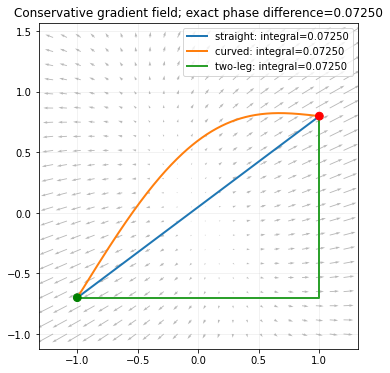

In [2]:
def potential(x,y): return .55*x*x+.25*y*y+.35*x*y
def grad(x,y): return 1.1*x+.35*y, .5*y+.35*x
def integrate_parametric(x,y):
    gx,gy=grad(x,y)
    return np.sum(.5*(gx[:-1]+gx[1:])*np.diff(x)+.5*(gy[:-1]+gy[1:])*np.diff(y))
n=300; s=np.linspace(0,1,n); start=(-1.,-.7); end=(1.,.8)
paths=[('straight',start[0]+(end[0]-start[0])*s,start[1]+(end[1]-start[1])*s),
       ('curved',start[0]+(end[0]-start[0])*s,start[1]+(end[1]-start[1])*s+.55*np.sin(np.pi*s)),
       ('two-leg',np.r_[np.linspace(start[0],end[0],n//2),np.full(n-n//2,end[0])],
                    np.r_[np.full(n//2,start[1]),np.linspace(start[1],end[1],n-n//2)])]
xx,yy=np.meshgrid(np.linspace(-1.2,1.2,22),np.linspace(-1,1.45,22)); gx,gy=grad(xx,yy)
fig,ax=plt.subplots(figsize=(8,6)); ax.quiver(xx,yy,gx,gy,color='.72')
for name,xp,yp in paths:
    value=integrate_parametric(xp,yp); ax.plot(xp,yp,lw=2,label=f'{name}: integral={value:.5f}')
exact=potential(*end)-potential(*start)
ax.scatter(*zip(start,end),c=['green','red'],s=60,zorder=4); ax.set_aspect('equal')
ax.set_title(f'Conservative gradient field; exact phase difference={exact:.5f}'); ax.legend(); ax.grid(alpha=.2)
plt.show(); plt.close(fig)

## 2.2 Differential forms and path independence

For a smooth 2-D field $(P,Q)$ on a simply connected region, path independence requires $\partial Q/\partial x-\partial P/\partial y=0$. This scalar curl measures local circulation. Adding a rotational component makes two paths disagree.

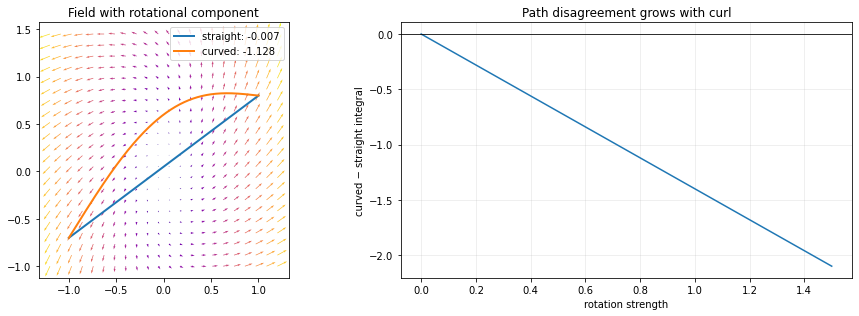

In [3]:
def field(x,y,rotation=0):
    gx,gy=grad(x,y)
    return gx-rotation*y, gy+rotation*x
def path_integral(x,y,rotation=0):
    p,q=field(x,y,rotation)
    return np.sum(.5*(p[:-1]+p[1:])*np.diff(x)+.5*(q[:-1]+q[1:])*np.diff(y))
rotations=np.linspace(0,1.5,80); discrepancies=[]
for r in rotations:
    vals=[path_integral(xp,yp,r) for _,xp,yp in paths[:2]]
    discrepancies.append(vals[1]-vals[0])
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ax[0].quiver(xx,yy,*field(xx,yy,.8),np.hypot(*field(xx,yy,.8)),cmap='plasma')
for name,xp,yp in paths[:2]: ax[0].plot(xp,yp,lw=2,label=f'{name}: {path_integral(xp,yp,.8):.3f}')
ax[0].set(title='Field with rotational component',aspect='equal'); ax[0].legend()
ax[1].plot(rotations,discrepancies); ax[1].axhline(0,color='k',lw=.8)
ax[1].set(xlabel='rotation strength',ylabel='curved − straight integral',title='Path disagreement grows with curl'); ax[1].grid(alpha=.25)
fig.tight_layout(); plt.show(); plt.close(fig)

## 2.3 Residues

A phase singularity has nonzero circulation even though its wrapped phase is defined away from the center. Summing wrapped phase differences around a small closed pixel loop gives approximately $+2\pi$, $-2\pi$, or zero. Dividing by $2\pi$ produces the integer residue charge.

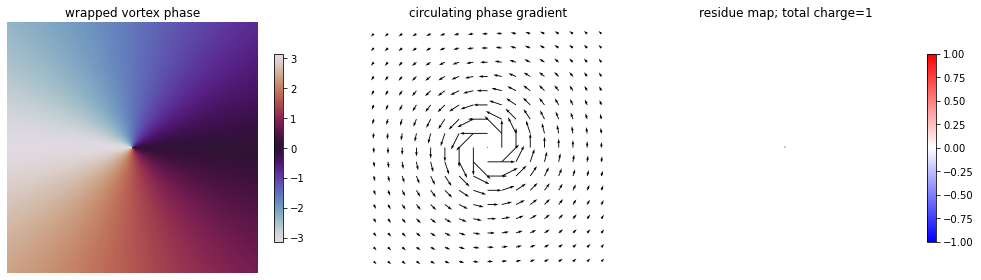

In [4]:
def phase_residues(phase):
    # Counter-clockwise circulation around each 2x2 cell.
    top=wrap_phase(phase[:-1,1:]-phase[:-1,:-1])
    right=wrap_phase(phase[1:,1:]-phase[:-1,1:])
    bottom=wrap_phase(phase[1:,:-1]-phase[1:,1:])
    left=wrap_phase(phase[:-1,:-1]-phase[1:,:-1])
    return np.rint((top+right+bottom+left)/TWO_PI).astype(np.int8)

y,x=np.mgrid[-1:1:241j,-1:1:241j]
vortex=wrap_phase(np.arctan2(y,x))
charges=phase_residues(vortex)
fig,ax=plt.subplots(1,3,figsize=(14,4))
m=ax[0].imshow(vortex,cmap='twilight',extent=[-1,1,1,-1]); ax[0].set_title('wrapped vortex phase'); fig.colorbar(m,ax=ax[0],shrink=.75)
step=15; ax[1].quiver(x[::step,::step],y[::step,::step],-y[::step,::step]/(x[::step,::step]**2+y[::step,::step]**2+.01),x[::step,::step]/(x[::step,::step]**2+y[::step,::step]**2+.01))
ax[1].set(title='circulating phase gradient',aspect='equal')
m=ax[2].imshow(charges,cmap='bwr',vmin=-1,vmax=1); ax[2].set_title(f'residue map; total charge={charges.sum()}'); fig.colorbar(m,ax=ax[2],shrink=.75)
for a in ax: a.axis('off')
fig.tight_layout(); plt.show(); plt.close(fig)

### Positive and negative residue pairs

In many finite images, singularities occur in opposite-charge pairs. A branch cut joins charges or connects them to the boundary, preventing an integration path from enclosing unbalanced charge.

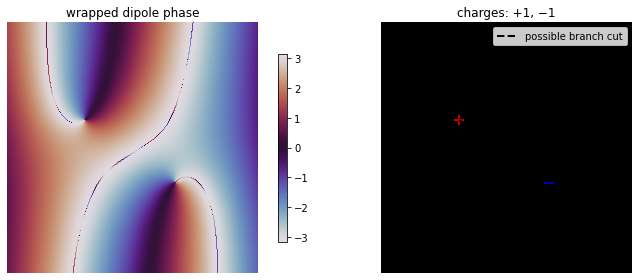

In [5]:
pair_phase=wrap_phase(np.arctan2(y+.22,x+.38)-np.arctan2(y-.28,x-.34)+5*x)
pair_charge=phase_residues(pair_phase); locations=np.argwhere(pair_charge!=0)
fig,ax=plt.subplots(1,2,figsize=(11,4))
m=ax[0].imshow(pair_phase,cmap='twilight'); ax[0].set_title('wrapped dipole phase'); fig.colorbar(m,ax=ax[0],shrink=.75)
ax[1].imshow(np.zeros_like(pair_charge),cmap='gray',vmin=0,vmax=1)
for row,col in locations:
    ax[1].scatter(col,row,c='red' if pair_charge[row,col]>0 else 'blue',s=90,marker='+' if pair_charge[row,col]>0 else '_')
if len(locations)==2: ax[1].plot(locations[:,1],locations[:,0],'k--',lw=2,label='possible branch cut')
ax[1].set_title(f'charges: +{np.sum(pair_charge>0)}, −{np.sum(pair_charge<0)}'); ax[1].legend()
for a in ax: a.axis('off')
fig.tight_layout(); plt.show(); plt.close(fig)

## 2.4 Irrotational and rotational decomposition

A sampled vector field can be separated into an irrotational (gradient) part and a divergence-free rotational part. The Fourier-domain projection below demonstrates this discrete Helmholtz decomposition on a periodic grid. The gradient component is compatible with a single-valued phase; the rotational component is responsible for circulation.

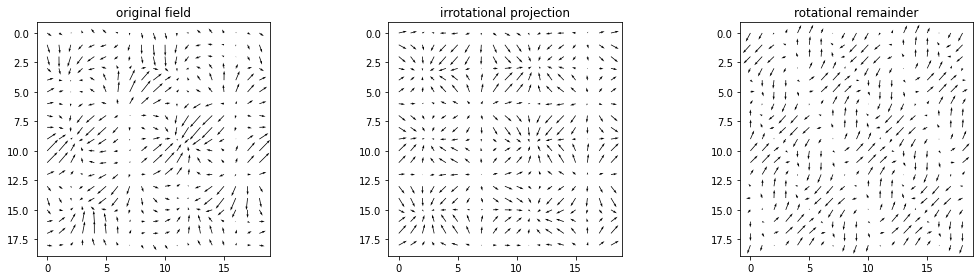

relative reconstruction error: 0.0


In [6]:
n=128; yy,xx=np.mgrid[0:n,0:n]/n*TWO_PI
scalar=np.sin(2*xx)+.7*np.cos(3*yy)+.35*np.sin(xx+2*yy)
stream=.8*np.sin(2*xx-yy)+.25*np.cos(3*yy)
gx=np.gradient(scalar,axis=1)+np.gradient(stream,axis=0)
gy=np.gradient(scalar,axis=0)-np.gradient(stream,axis=1)
ky=TWO_PI*np.fft.fftfreq(n)[:,None]; kx=TWO_PI*np.fft.fftfreq(n)[None,:]
Gx,Gy=np.fft.fft2(gx),np.fft.fft2(gy); k2=kx*kx+ky*ky; k2[0,0]=1
projection=(kx*Gx+ky*Gy)/k2
Ix=np.fft.ifft2(kx*projection).real; Iy=np.fft.ifft2(ky*projection).real
Rx,Ry=gx-Ix,gy-Iy
fig,ax=plt.subplots(1,3,figsize=(15,4)); step=7
for a,u,v,title in zip(ax,[gx,Ix,Rx],[gy,Iy,Ry],['original field','irrotational projection','rotational remainder']):
    a.quiver(u[::step,::step],v[::step,::step]); a.set(title=title,aspect='equal'); a.invert_yaxis()
fig.tight_layout(); plt.show(); plt.close(fig)
print('relative reconstruction error:',np.linalg.norm(gx-Ix-Rx)+np.linalg.norm(gy-Iy-Ry))

## 2.5 Discrete formulation of 2-D phase unwrapping

The data are wrapped horizontal and vertical differences. If they are consistent, summing them along any grid path recovers the same phase. The code below integrates first horizontally then vertically, and in the reverse order.

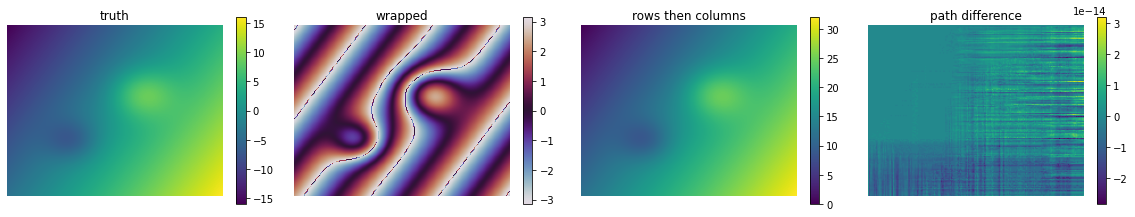

row/column path disagreement: 3.197442310920451e-14


In [7]:
def integrate_rows_columns(phase):
    dx=wrap_phase(np.diff(phase,axis=1)); dy=wrap_phase(np.diff(phase,axis=0))
    out=np.zeros_like(phase); out[0,1:]=np.cumsum(dx[0])
    out[1:]=out[0]+np.cumsum(dy,axis=0)
    return out
def integrate_columns_rows(phase):
    dx=wrap_phase(np.diff(phase,axis=1)); dy=wrap_phase(np.diff(phase,axis=0))
    out=np.zeros_like(phase); out[1:,0]=np.cumsum(dy[:,0])
    out[:,1:]=out[:,[0]]+np.cumsum(dx,axis=1)
    return out
truth,wrapped,_=make_synthetic((150,190),noise=0,seed=3)
rc=integrate_rows_columns(wrapped); cr=integrate_columns_rows(wrapped)
fig,ax=plt.subplots(1,4,figsize=(16,4))
for a,image,title in zip(ax,[truth,wrapped,rc,rc-cr],['truth','wrapped','rows then columns','path difference']):
    m=a.imshow(image,cmap='twilight' if title=='wrapped' else 'viridis'); a.set_title(title); a.axis('off'); fig.colorbar(m,ax=a,shrink=.7)
fig.tight_layout(); plt.show(); plt.close(fig)
print('row/column path disagreement:',np.max(np.abs(rc-cr)))

## 2.6 Simple tests for path dependence

The discrete curl is the sum of oriented wrapped differences around each $2\times2$ cell. Zero curl means local path independence. Nonzero integer curl is exactly the residue test. Noise creates residue pairs once wrapped differences cross the principal-interval boundary.

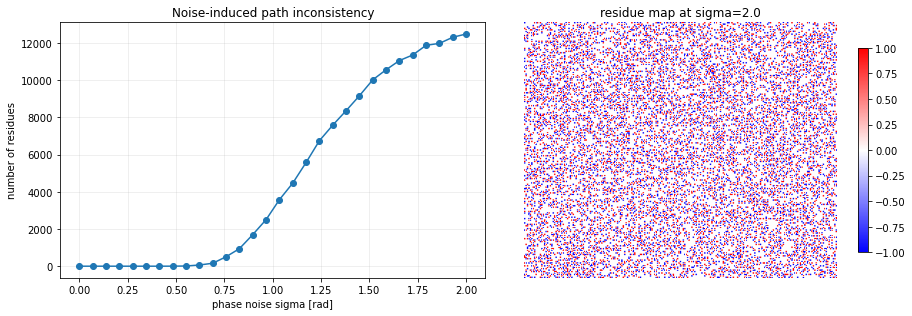

In [8]:
rng=np.random.default_rng(5); sigmas=np.linspace(0,2,30); counts=[]
base_truth,base_wrapped,_=make_synthetic((180,220),noise=0,seed=4)
examples=[]
for sigma in sigmas:
    noisy=wrap_phase(base_truth+rng.normal(0,sigma,base_truth.shape))
    charge=phase_residues(noisy); counts.append(np.count_nonzero(charge))
    if sigma in (sigmas[0],sigmas[len(sigmas)//2],sigmas[-1]): examples.append((sigma,noisy,charge))
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ax[0].plot(sigmas,counts,'o-'); ax[0].set(xlabel='phase noise sigma [rad]',ylabel='number of residues',title='Noise-induced path inconsistency'); ax[0].grid(alpha=.25)
sigma,noisy,charge=examples[-1]; m=ax[1].imshow(charge,cmap='bwr',vmin=-1,vmax=1)
ax[1].set_title(f'residue map at sigma={sigma:.1f}'); ax[1].axis('off'); fig.colorbar(m,ax=ax[1],shrink=.8)
fig.tight_layout(); plt.show(); plt.close(fig)

## 2.7 Residues, gradients, and decomposition: example

A difficult wrapped surface is analyzed through its residues and then reconstructed globally. Least squares does not explicitly draw branch cuts; it finds a phase whose gradient best matches the inconsistent wrapped-gradient field.

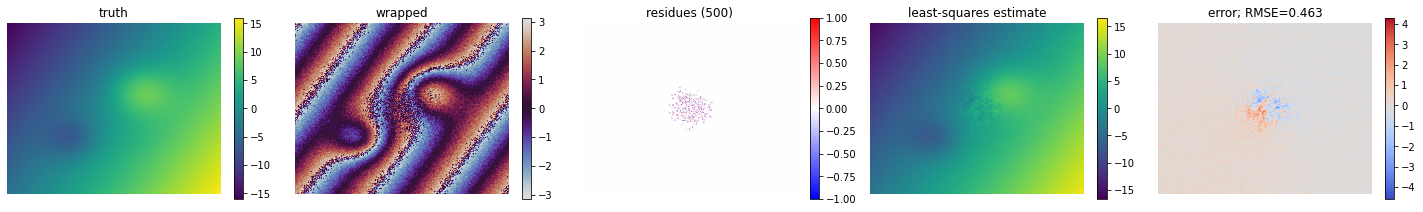

Info(backend='numba', iterations=22, relative_residual=6.293007726137806e-08, converged=True)


In [9]:
truth,wrapped,weight=make_synthetic((256,320),noise=.35,seed=20)
charge=phase_residues(wrapped)
estimate,info=unwrap(wrapped,weight,backend='numba',max_iter=150,tol=1e-7,return_info=True)
aligned=estimate+np.mean(truth-estimate); error=aligned-truth
fig,ax=plt.subplots(1,5,figsize=(20,4))
panels=[(truth,'truth','viridis'),(wrapped,'wrapped','twilight'),(charge,f'residues ({np.count_nonzero(charge)})','bwr'),
        (aligned,'least-squares estimate','viridis'),(error,f'error; RMSE={rmse_aligned(estimate,truth):.3f}','coolwarm')]
for a,(image,title,cmap) in zip(ax,panels):
    kw={'vmin':-1,'vmax':1} if title.startswith('residues') else {}
    m=a.imshow(image,cmap=cmap,**kw); a.set_title(title); a.axis('off'); fig.colorbar(m,ax=a,shrink=.68)
fig.tight_layout(); plt.show(); plt.close(fig)
print(info)

## Chapter 2 takeaways

1. Unwrapping is discrete integration of wrapped phase differences.
2. A true gradient field is path independent; curl measures inconsistency.
3. A residue is an integer nonzero circulation around one grid cell.
4. Opposite residues motivate branch cuts and path planning.
5. Gradient decomposition separates integrable and rotational content.
6. Branch-cut, quality-guided, and least-squares algorithms handle inconsistent gradients differently.